# Week 3

THe goal of this week is to: 

1. [x] Confirm that me and Jan gets the same likelihood values given the same parameters
2. [x] Research why the phi values in notebook week_2 is over 1 and what this means
3. [x] Create a profile likelihood plot of phi 
4. [] Make mu non-free in the sense that thay are bounded by a sorted order
5. [] Interpretet the states and make sure they make sense

## Config

In [1]:
import jax 
from src.data import load_model_and_data 
from src.optim.loss import negative_log_likelihood

jax.config.update("jax_enable_x64", True)  # Enable 64-bit precision for JAX 

class MODELTYPES: 
    StationaryHMM = "stationary_hmm_4_state" 
    AR1 = "ar1_model" 
    AR2 = "ar2_model" 
    AR_HMM = "ar_hmm_model"
    COVARIATE_HMM = "covariate_hmm_model"
    COVARIATE_AR_HMM = "covariate_ar_hmm_model"  



RUN_TO_LOAD = {
    "tag": "week_2",
    "run": 1
}


## 1. Confirming Likelihoods and model params

Checked that me and Jan has the exact same y values

### Stationary HMM

In [2]:
from src.models.v1.stationary_hmm import StationaryHMM
from src.deprecated.base.hmm_params import HMMParams
import jax.numpy as jnp

params, y, X = load_model_and_data(modelname=MODELTYPES.StationaryHMM, tag=RUN_TO_LOAD["tag"], run=RUN_TO_LOAD["run"])
model = StationaryHMM(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma))
params

model: StationaryHMM
mu:    [ 535.64741812  890.00396553 1306.52667247]
sigma: [ 21.72799795  76.58949195 111.00710845 197.39770935]
initial_state_dist:  None
transition_matrix:
[[8.49417101e-01 1.47756510e-01 2.82638881e-03 2.14897417e-17]
 [8.25318826e-02 8.49531488e-01 6.79366297e-02 6.60630290e-15]
 [4.27781253e-04 1.61716562e-01 6.84203524e-01 1.53652133e-01]
 [3.14348210e-13 4.29480427e-16 7.23388998e-02 9.27661100e-01]]

In [3]:
mu, sigma, transition_matrix = model.mu(), model.sigma(), model.transition_matrix()

for i, (m, s) in enumerate(zip(mu, sigma)):
    print(f"State {i}: mu={m:.4f}, sigma={s:.4f}") 

State 0: mu=400.0000, sigma=21.7280
State 1: mu=535.6474, sigma=76.5895
State 2: mu=890.0040, sigma=111.0071
State 3: mu=1306.5267, sigma=197.3977


![Results for 4 states](images/jans_book/stationary/results_4_states.png)

In [4]:
print("Transition Matrix:")
print(transition_matrix)

print("State distribution")
print(model.transition.u0())

Transition Matrix:
[[8.49417101e-01 1.47756510e-01 2.82638881e-03 2.14897417e-17]
 [8.25318826e-02 8.49531488e-01 6.79366297e-02 6.60630290e-15]
 [4.27781253e-04 1.61716562e-01 6.84203524e-01 1.53652133e-01]
 [3.14348210e-13 4.29480427e-16 7.23388998e-02 9.27661100e-01]]
State distribution
[0.19019046 0.34624139 0.14838646 0.31518169]


![Results for 4 states](images/jans_book/stationary/results_transition.png)

In [5]:
JANS_LIKELIHOOD = -10389.0 

print(f"Log-Likelihood: {-negative_log_likelihood(model, y, X):.4f}")

Log-Likelihood: -10388.6807


### Auto Regressive Model

In [6]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

model, y, X = load_model_and_data(modelname=MODELTYPES.AR2, tag=RUN_TO_LOAD["tag"], run=RUN_TO_LOAD["run"])

JANS_LIKELIHOOD = -10207.0 

y_np = np.array(y)  # Convert JAX array to NumPy array 


model = ARIMA(y_np, order=(2, 0, 0)).fit()

print(f"Log-Likelihood of AR(2) model: {model.llf:.4f}") 
print(f"Jans log-likelihood: {JANS_LIKELIHOOD:.4f}")
print(model.summary())  



Log-Likelihood of AR(2) model: -10207.1111
Jans log-likelihood: -10207.0000
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1666
Model:                 ARIMA(2, 0, 0)   Log Likelihood              -10207.111
Date:                Mon, 06 Apr 2026   AIC                          20422.222
Time:                        09:09:31   BIC                          20443.895
Sample:                             0   HQIC                         20430.254
                               - 1666                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        805.6580     48.949     16.459      0.000     709.719     901.597
ar.L1          1.3033      0.015     84.654      0.000 

|        | ar1    | ar2     | intercept |
|--------|--------|---------|-----------|
| value  | 1.3033 | -0.3696 | 805.7683  |
| s.e.   | 0.0228 | 0.0228  | 40.7347   |

We get the exact same vals

### HMM Autoregressive model

In [7]:
import jax.numpy as jnp
from src.models.v1.ar_hmm import ArHMM

params, y, X = load_model_and_data(modelname=MODELTYPES.AR_HMM, tag=RUN_TO_LOAD["tag"], run=RUN_TO_LOAD["run"])
model = ArHMM(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma), phi=params.phi)
params

model: ArHMM
mu:    [ 535.68046261  889.93105469 1306.70139423]
sigma: [  0.4363331   39.538437   187.60279154  39.96637215]
phi:   [1.00005795 1.03787735 0.7414197  0.642594  ]
initial_state_dist:  None
transition_matrix:
[[5.17866542e-01 4.77790595e-01 4.34286321e-03 1.31017120e-17]
 [1.23282628e-01 7.07296253e-01 1.69421119e-01 5.50022377e-15]
 [3.97409097e-04 3.08985045e-01 5.82350886e-01 1.08266660e-01]
 [2.53832161e-13 3.46799955e-16 2.50925520e-01 7.49074480e-01]]

In [8]:
JANS_LIKELIHOOD = -9354.0 
print(f"Log-Likelihood of AR-HMM model: {-negative_log_likelihood(model, y, X):.4f}")
print(f"Jans log-likelihood: {JANS_LIKELIHOOD:.4f}")

Log-Likelihood of AR-HMM model: -9145.6768
Jans log-likelihood: -9354.0000


In [9]:
mu, sigma, transition_matrix = model.emission.mu, jnp.exp(model.emission.log_sigma), model.transition.transition_matrix
phi = model.emission.phi 
mu = jnp.concatenate([jnp.array([400.0]), mu])  # Add zero for the first state (AR(2) state)

for i, (m, s) in enumerate(zip(mu, sigma)):
    print(f"State {i}: mu={m:.4f}, sigma={s:.4f}, phi={phi[i]:.4f}")

State 0: mu=400.0000, sigma=0.4363, phi=1.0001
State 1: mu=535.6805, sigma=39.5384, phi=1.0379
State 2: mu=889.9311, sigma=187.6028, phi=0.7414
State 3: mu=1306.7014, sigma=39.9664, phi=0.6426


![Results for 4 states ArrHmm](images/jans_book/arr_hmm/params.png)

![Results for 4 states ArrHmm](images/jans_book/arr_hmm/tpm.png)

We now test that given Jans parameters, we will get the same likelihood

In [12]:
from src.models.v1.ar_hmm import ArHMM  
from src.optim.minimizer import Minimizer 

#JANS RESULTS 
mu = jnp.array([453, 730, 1590]) 
sigma = jnp.array([13, 42, 108, 72]) 
phi = jnp.array([0.97, 0.30, 0.62, 0.85 ]) 


Gamma = jnp.array([
    [8.2e-01, 0.0946, 0.0870, 9.3e-09],
    [1.8e-01, 0.6875, 0.1360, 5.5e-09],
    [9.6e-02, 0.2104, 0.4140, 2.8e-01],
    [2.3e-08, 0.0049, 0.1330, 8.6e-01],
])

stat_dist = jnp.array([[0.29, 0.21, 0.17, 0.34]])


## CONVERTING TO MODEL PARAMS 
num_states = 4
tGamma = jnp.zeros((num_states, num_states))
tGamma = tGamma.at[jnp.diag_indices(num_states)].set(0.0)
rows, cols = jnp.where(~jnp.eye(num_states, dtype=bool), size=num_states * (num_states - 1))
tGamma = tGamma.at[rows, cols].set(jnp.log(Gamma[rows, cols])) 

offdiag_mask = ~jnp.eye(num_states, dtype=bool)
tGamma_no_diag = tGamma[offdiag_mask].reshape(num_states, num_states - 1)


class ArHMMTest(ArHMM): 
    tpm : jnp.ndarray 
    def __init__(self, mu, log_sigma, phi, transition_logits, tpm):
    
        self.tpm = tpm
        super().__init__(mu=mu, log_sigma=log_sigma, phi=phi, transition_logits=transition_logits)


    def transition_matrix(self, xt = None): 
        return self.tpm 
    



arr_hmm_test = ArHMMTest(mu=mu, log_sigma=jnp.log(sigma), phi=phi, transition_logits=tGamma_no_diag, tpm=Gamma)

x =  y[:-1]  # Lagged observations for AR component 
X = jnp.stack([x,x,x,x], axis=1)  # Same lagged observations for each state, shape (T, num_states) 

print(f"Log-Likelihood of AR-HMM model with Jans parameters: {-negative_log_likelihood(arr_hmm_test, y[1:], X):.4f}")
print(f"Jans log-likelihood: {JANS_LIKELIHOOD:.4f}")





for i, (m_jan, m, s_jan, s, p_jan, p) in enumerate(zip(mu, arr_hmm_test.emission.mu, sigma, arr_hmm_test.emission.log_sigma, phi, arr_hmm_test.emission.phi)):
    
    print(f"State {i}:")
    print(f"  Jans mu: {m_jan:.4f}, Model mu: {m:.4f}")
    print(f"  Jans sigma: {s_jan:.4f}, Model sigma: {jnp.exp(s):.4f}")
    print(f"  Jans phi: {p_jan:.4f}, Model phi: {p:.4f}")
    print()


Gamma_from_model = arr_hmm_test.transition_matrix()

for i in range(num_states):
    print(f"State {i} transition probabilities:") 
    for j in range(num_states):
        print(f"  To state {j}: {Gamma_from_model[i, j]:.4f} (Jans: {Gamma[i, j]:.4f})")


print("Stationary distribution from model:")
print(arr_hmm_test.transition.u0())
print("Stationary distribution from Jans:")
print(stat_dist)

Log-Likelihood of AR-HMM model with Jans parameters: -9354.5125
Jans log-likelihood: -9354.0000
State 0:
  Jans mu: 453.0000, Model mu: 453.0000
  Jans sigma: 13.0000, Model sigma: 13.0000
  Jans phi: 0.9700, Model phi: 0.9700

State 1:
  Jans mu: 730.0000, Model mu: 730.0000
  Jans sigma: 42.0000, Model sigma: 42.0000
  Jans phi: 0.3000, Model phi: 0.3000

State 2:
  Jans mu: 1590.0000, Model mu: 1590.0000
  Jans sigma: 108.0000, Model sigma: 108.0000
  Jans phi: 0.6200, Model phi: 0.6200

State 0 transition probabilities:
  To state 0: 0.8200 (Jans: 0.8200)
  To state 1: 0.0946 (Jans: 0.0946)
  To state 2: 0.0870 (Jans: 0.0870)
  To state 3: 0.0000 (Jans: 0.0000)
State 1 transition probabilities:
  To state 0: 0.1800 (Jans: 0.1800)
  To state 1: 0.6875 (Jans: 0.6875)
  To state 2: 0.1360 (Jans: 0.1360)
  To state 3: 0.0000 (Jans: 0.0000)
State 2 transition probabilities:
  To state 0: 0.0960 (Jans: 0.0960)
  To state 1: 0.2104 (Jans: 0.2104)
  To state 2: 0.4140 (Jans: 0.4140)
  To s

Finding optium

In [13]:
#Init of new model 
ar_hmm_jans = ArHMM(mu=mu, log_sigma=jnp.log(sigma), phi=phi, transition_logits=tGamma_no_diag)


optimizer = Minimizer(model=ar_hmm_jans, loss_fn = negative_log_likelihood) 

opt_model = optimizer.run(y[1:], X)  



print(f"Log-Likelihood of AR-HMM model: {-negative_log_likelihood(opt_model, y[1:], X):.4f}")
print(f"Jans log-likelihood: {JANS_LIKELIHOOD:.4f}")
print()


for i, (m_jan, m, s_jan, s, p_jan, p) in enumerate(zip(mu, opt_model.emission.mu, sigma, opt_model.emission.log_sigma, phi, opt_model.emission.phi)):
    
    print(f"State {i}:")
    print(f"  Jans mu: {m_jan:.4f}, Model mu: {m:.4f}")
    print(f"  Jans sigma: {s_jan:.4f}, Model sigma: {jnp.exp(s):.4f}")
    print(f"  Jans phi: {p_jan:.4f}, Model phi: {p:.4f}")
    print()


Gamma_from_model = opt_model.transition.transition_matrix()

for i in range(num_states):
    print(f"State {i} transition probabilities:") 
    for j in range(num_states):
        print(f"  To state {j}: {Gamma_from_model[i, j]:.4f} (Jans: {Gamma[i, j]:.4f})")


print("Stationary distribution from model:")
print(opt_model.transition.u0())
print("Stationary distribution from Jans:")
print(stat_dist)

Log-Likelihood of AR-HMM model: -9354.1796
Jans log-likelihood: -9354.0000

State 0:
  Jans mu: 453.0000, Model mu: 453.0000
  Jans sigma: 13.0000, Model sigma: 13.3210
  Jans phi: 0.9700, Model phi: 0.9731

State 1:
  Jans mu: 730.0000, Model mu: 730.0000
  Jans sigma: 42.0000, Model sigma: 41.4154
  Jans phi: 0.3000, Model phi: 0.2936

State 2:
  Jans mu: 1590.0000, Model mu: 1590.0000
  Jans sigma: 108.0000, Model sigma: 107.3350
  Jans phi: 0.6200, Model phi: 0.6264

State 0 transition probabilities:
  To state 0: 0.8180 (Jans: 0.8200)
  To state 1: 0.0884 (Jans: 0.0946)
  To state 2: 0.0937 (Jans: 0.0870)
  To state 3: 0.0000 (Jans: 0.0000)
State 1 transition probabilities:
  To state 0: 0.1745 (Jans: 0.1800)
  To state 1: 0.6715 (Jans: 0.6875)
  To state 2: 0.1366 (Jans: 0.1360)
  To state 3: 0.0173 (Jans: 0.0000)
State 2 transition probabilities:
  To state 0: 0.0984 (Jans: 0.0960)
  To state 1: 0.2136 (Jans: 0.2104)
  To state 2: 0.4149 (Jans: 0.4140)
  To state 3: 0.2732 (Jans

In [16]:
import equinox as eqx
from src.optim.loss import profile_likelihood 



def make_loss_fixed_phi0(phi0):
    """Returns a loss function with phi[0] pinned to phi0."""
    def loss(m, y, X):
        phi_fixed = m.emission.phi.at[0].set(phi0)
        m_fixed = eqx.tree_at(lambda z: z.emission.phi, m, phi_fixed)
        return negative_log_likelihood(m_fixed, y, X)
    return loss







#We know load the orignal model and plot that likelihood as well for comparison
params, y, X = load_model_and_data(modelname=MODELTYPES.AR_HMM, tag=RUN_TO_LOAD["tag"], run=RUN_TO_LOAD["run"]) 
model = ArHMM(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma), phi=params.phi)

models_to_plot = {
    "Jans AR-HMM": ar_hmm_jans,
    "Original AR-HMM": model
}


y = y[1:]  # Align with lagged X 
X = X[1:]  # Align with y 


Jans AR-HMM - Max Log-Likelihood: -9354.8601 at phi[0]=0.9758
Original AR-HMM - Max Log-Likelihood: -9144.8771 at phi[0]=0.9970


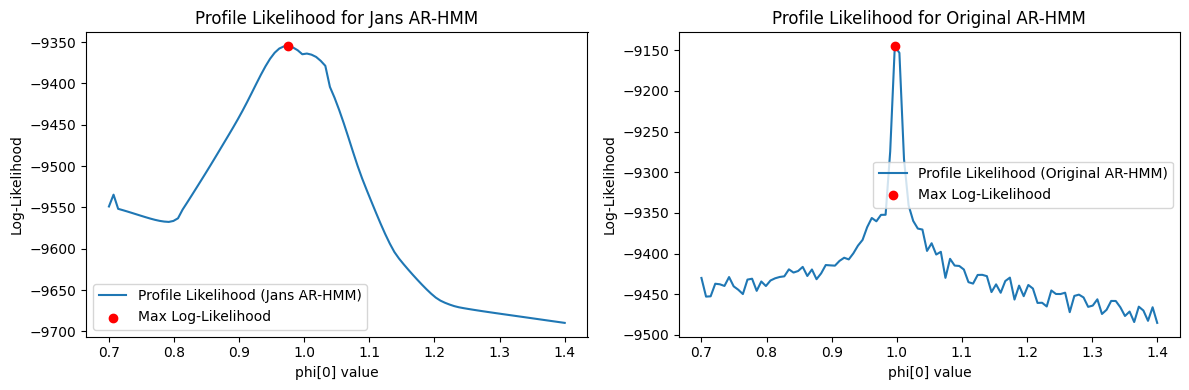

In [17]:
import matplotlib.pyplot as plt

phi_range = (0.7, 1.4)


n_models = len(models_to_plot)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4))

if n_models == 1:
    axes = [axes]
axes = axes.flatten() 

for i, (model_name, model) in enumerate(models_to_plot.items()):
    phi_space, log_likes = profile_likelihood(
        model=model,  
        y=y, X=X, 
        phi_range=phi_range, 
        loss_generator=make_loss_fixed_phi0, 
        num_points=100
    )

    # Plotting
    ax = axes[i]
    #print max log-likelihood and corresponding phi value in the plot
    max_idx = jnp.argmax(log_likes)
    print(f"{model_name} - Max Log-Likelihood: {log_likes[max_idx]:.4f} at phi[0]={phi_space[max_idx]:.4f}")
    ax.plot(phi_space, log_likes, label=f'Profile Likelihood ({model_name})')
    ax.set_title(f'Profile Likelihood for {model_name}')
    ax.set_xlabel('phi[0] value')
    ax.set_ylabel('Log-Likelihood')
    #Plot point of max log-likelihood and value of phi[0] at that point
    ax.scatter(phi_space[max_idx], log_likes[max_idx], color='red', label='Max Log-Likelihood', zorder=5)
    ax.legend()

plt.tight_layout()
plt.show()


The reason i got a different Phi value was because i conditioned the first y0 value on being equal phi. This of course would jamp up the phi values such that the initial y0 is more close to phi0. 

Look into conditional and non-condition MLE. 

IN PROFILE LIKELIHOOD PICTURE \
Jans AR-HMM - Max Log-Likelihood: -9354.8601 at phi[0]=0.9758 \
Original AR-HMM - Max Log-Likelihood: -9144.8771 at phi[0]=0.9970

In [ ]:
from src.optim.lbfgs import LFBGSOptimizer
from src.data import save_model_and_data
from src.models.v1.ar_hmm import ArHMM

params, _, _ = load_model_and_data(modelname=MODELTYPES.AR_HMM, tag=RUN_TO_LOAD["tag"], run=RUN_TO_LOAD["run"])
model = ArHMM(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma), phi=params.phi)

optimizer = LFBGSOptimizer(
    model=model,
    loss_fn=negative_log_likelihood
)

opt_model = optimizer.run(y, X)

print(f"Log-Likelihood of AR-HMM model: {-negative_log_likelihood(opt_model, y, X):.4f}")

save_model_and_data(model=opt_model, y=y, X=X, modelname=MODELTYPES.AR_HMM, tag="week_3", run=1)